# Statistical Modeling and Inferencing – Assignment 1
### Name: Chetan Pant
### Roll number: 1100372
### Chosen Dataset: Dataset 2: Wholesale Customer Dataset
### Submission Date: 03/12/2025
###Google Colab Notebook Link: https://colab.research.google.com/drive/1O-09WQi7rzNowzPyAthvQDm9GhUKv3qX?usp=sharing

### Summary
In this assignment, I analysed the Wholesale Customers Dataset to explore customer purchasing patterns and identify natural groupings using clustering techniques. I began with data exploration, where I examined distributions, descriptive statistics, correlations, and potential data quality issues. All six spending variables showed right-skewed distributions with several high-value outliers, which is expected in wholesale settings. Since missing values were absent and outliers reflected genuine high-spending customers, no rows were removed. The variables were then standardised to ensure equal contribution to distance-based clustering methods.

For clustering, I applied K-means and evaluated different values of K using both the Elbow method and Silhouette scores. While the Elbow plot suggested diminishing returns after K ≈ 4–5, the Silhouette scores were highest for K = 2 and K = 3. To balance model quality and interpretability, I selected K = 3 as the final solution. I then profiled each cluster using the mean spending values.

Three distinct customer segments emerged:

**Cluster 1:** (Majority Group): Low-to-moderate buyers across all categories—representing regular, everyday customers.

**Cluster 0:** High spenders in Grocery, Milk, and Detergents/Paper—likely retail shops, restaurants, or hotels.

**Cluster 2:** A very small set of extremely high-volume buyers—likely large distributors or industrial consumers.

Overall, the clustering analysis provided clear insights into different types of wholesale customer behaviours. These segments could help businesses tailor marketing efforts, optimise inventory planning, and design targeted promotions based on customer needs.

### **Part 1 – Data Exploration & Preparation**
### 1.1 Load Dataset and Basic Info
### 1.2 Descriptive Statistics
### 1.3 Data Quality Checks (Missing Values & Outliers)
### 1.4 Distribution Plots
### 1.5 Correlation Analysis
### 1.6 Encoding Categorical Variables
### 1.7 Feature Transformation (Scaling)

In [1]:
# 1. Basic Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots show inside the notebook
%matplotlib inline

In [2]:
# Step 2: Load the Wholesale Customers dataset

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00292/Wholesale%20customers%20data.csv"

df = pd.read_csv(url)  # let pandas use the first row as header automatically

# Look at the first few rows
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [3]:
# Step 3a: Shape of the dataset
print("Shape of dataset:", df.shape)

# Step 3b: Data types
print("\nData types:")
print(df.dtypes)

# Step 3c: Summary statistics for numeric variables
df.describe()

Shape of dataset: (440, 8)

Data types:
Channel             int64
Region              int64
Fresh               int64
Milk                int64
Grocery             int64
Frozen              int64
Detergents_Paper    int64
Delicassen          int64
dtype: object


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


In [4]:
numeric_cols = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']

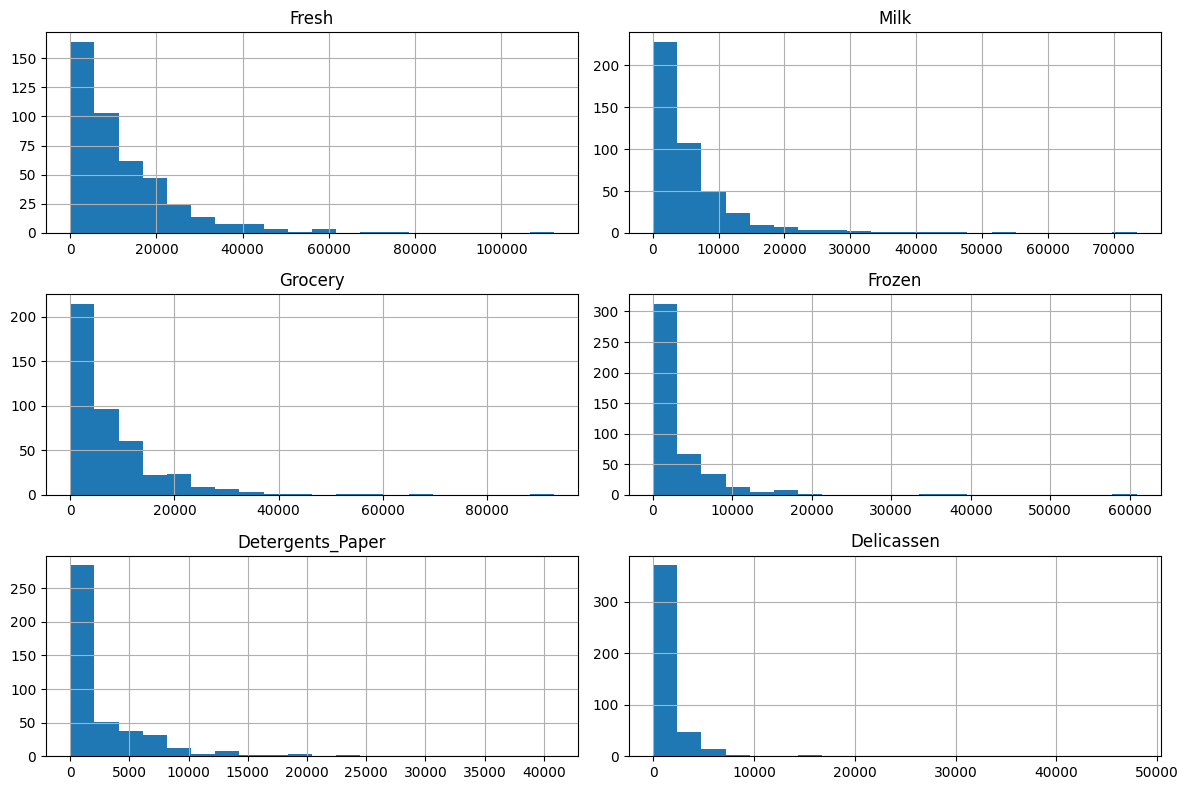

In [5]:
# Step 5: Histograms of numeric features

df[numeric_cols].hist(bins=20, figsize=(12, 8))
plt.tight_layout()
plt.show()

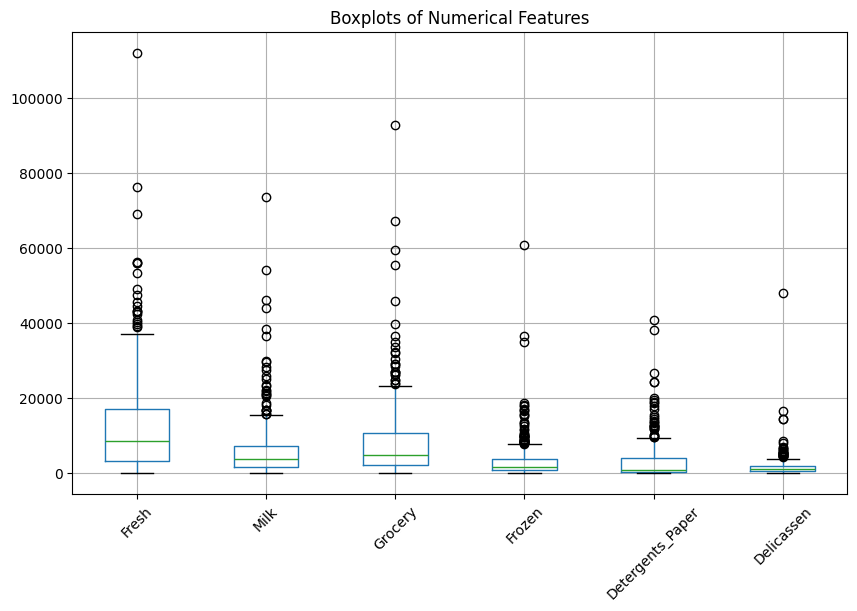

In [6]:
# Step 6: Boxplots for numeric features

plt.figure(figsize=(10, 6))
df[numeric_cols].boxplot()
plt.xticks(rotation=45)
plt.title("Boxplots of Numerical Features")
plt.show()

In [7]:
# 7.1 Missing values check
df.isna().sum()

,0
Channel,0
Region,0
Fresh,0
Milk,0
Grocery,0
Frozen,0
Detergents_Paper,0
Delicassen,0


In [8]:
# 8.1 Correlation matrix for numeric features
corr_matrix = df[numeric_cols].corr()
corr_matrix

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Fresh,1.000000,0.100510,-0.011854,0.345881,-0.101953,0.244690
Milk,0.100510,1.000000,0.728335,0.123994,0.661816,0.406368
Grocery,-0.011854,0.728335,1.000000,-0.040193,0.924641,0.205497
Frozen,0.345881,0.123994,-0.040193,1.000000,-0.131525,0.390947
Detergents_Paper,-0.101953,0.661816,0.924641,-0.131525,1.000000,0.069291
Delicassen,0.244690,0.406368,0.205497,0.390947,0.069291,1.000000


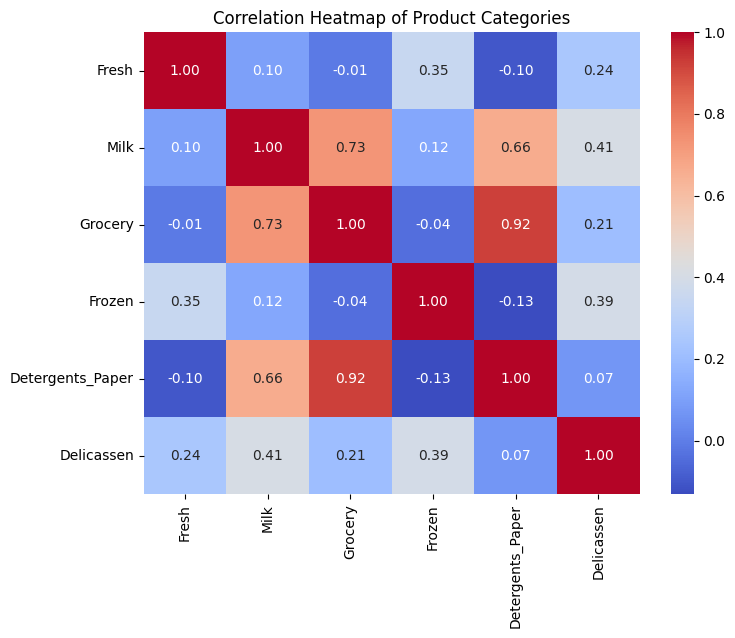

In [9]:
# 8.2 Correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap of Product Categories")
plt.show()

In [10]:
# 9.1 Function to count IQR-based outliers
def count_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return ((series < lower) | (series > upper)).sum()

for col in numeric_cols:
    print(col, "-> IQR outliers:", count_outliers_iqr(df[col]))

Fresh -> IQR outliers: 20
Milk -> IQR outliers: 28
Grocery -> IQR outliers: 24
Frozen -> IQR outliers: 43
Detergents_Paper -> IQR outliers: 30
Delicassen -> IQR outliers: 27


Using the IQR rule (1.5 × IQR beyond the first or third quartile), I found outliers in all six spending variables. This confirms the long right tails seen in the histograms and boxplots.
Since these high values likely correspond to genuine high-spending customers, and clustering should be able to capture them as separate groups, I decided to keep the outliers rather than remove them. To reduce the impact of scale and extreme values, I use feature scaling in the next step

In [11]:
# 10.1 Check value counts
print("Channel value counts:")
print(df['Channel'].value_counts())

print("\nRegion value counts:")
print(df['Region'].value_counts())

Channel value counts:
Channel
1    298
2    142
Name: count, dtype: int64

Region value counts:
Region
3    316
1     77
2     47
Name: count, dtype: int64


In [12]:
# 10.2 One-hot encode Channel and Region
df_encoded = pd.get_dummies(df, columns=['Channel', 'Region'], drop_first=True)

df_encoded.head()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Channel_2,Region_2,Region_3
0,12669,9656,7561,214,2674,1338,True,False,True
1,7057,9810,9568,1762,3293,1776,True,False,True
2,6353,8808,7684,2405,3516,7844,True,False,True
3,13265,1196,4221,6404,507,1788,False,False,True
4,22615,5410,7198,3915,1777,5185,True,False,True


Channel and Region are categorical variables coded as integers. I converted them into dummy variables using one-hot encoding (with the first category dropped for each to avoid redundancy). This allows clustering algorithms to treat them as categories rather than as ordered numeric scales.

In [13]:
from sklearn.preprocessing import StandardScaler

# 11.1 Keep only the numeric spending variables for scaling
X_num = df[numeric_cols].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_num)

# Convert back to a DataFrame for convenience
X_scaled_df = pd.DataFrame(X_scaled, columns=numeric_cols)

X_scaled_df.head()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,0.052933,0.523568,-0.041115,-0.589367,-0.043569,-0.066339
1,-0.391302,0.544458,0.170318,-0.270136,0.086407,0.089151
2,-0.447029,0.408538,-0.028157,-0.137536,0.133232,2.243293
3,0.100111,-0.624020,-0.392977,0.687144,-0.498588,0.093411
4,0.840239,-0.052396,-0.079356,0.173859,-0.231918,1.299347


The six spending variables are on very different scales and are right-skewed. To make them comparable for distance-based clustering methods, I standardized them using z-scores (subtracting the mean and dividing by the standard deviation for each feature). After scaling, each variable has mean 0 and standard deviation 1, which prevents features with larger numeric ranges from dominating the clustering process.

## Part 2: Model Development and Validation
### Clustering Analysis

In [14]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [15]:
# Use only the 6 spending variables for clustering
numeric_cols = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']

X_num = df[numeric_cols].copy()

# Standardize features (z-score)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_num)

X_scaled[:5]

array([[ 0.05293319,  0.52356777, -0.04111489, -0.58936716, -0.04356873,
        -0.06633906],
       [-0.39130197,  0.54445767,  0.17031835, -0.27013618,  0.08640684,
         0.08915105],
       [-0.44702926,  0.40853771, -0.0281571 , -0.13753572,  0.13323164,
         2.24329255],
       [ 0.10011141, -0.62401993, -0.3929769 ,  0.6871443 , -0.49858822,
         0.09341105],
       [ 0.84023948, -0.05239645, -0.07935618,  0.17385884, -0.23191782,
         1.29934689]])

I used the six spending variables as input features for clustering and standardized them using z-scores so that each feature contributes equally to the distance-based K-means algorithm.

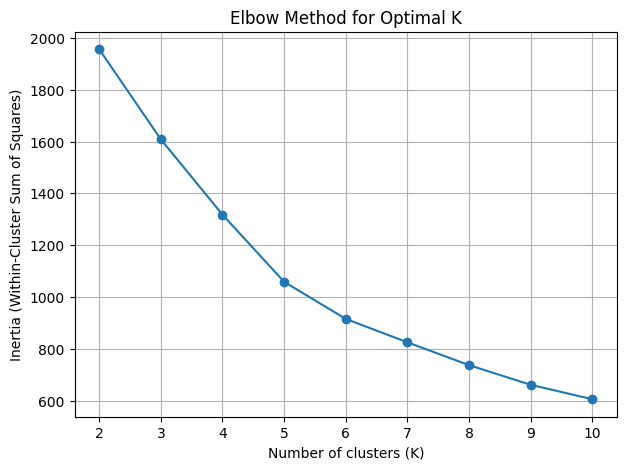

In [16]:
# Elbow method to choose K
inertia = []
K_values = range(2, 11)  # try K from 2 to 10

for k in K_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10,
        max_iter=300,
        tol=1e-4
    )
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot elbow curve
plt.figure(figsize=(7, 5))
plt.plot(K_values, inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.grid(True)
plt.show()

In [17]:
silhouette_scores = []

for k in K_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10,
        max_iter=300,
        tol=1e-4
    )
    labels_k = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels_k)
    silhouette_scores.append(score)
    print(f"K={k}, Silhouette Score={score:.4f}")

K=2, Silhouette Score=0.5472
K=3, Silhouette Score=0.5483
K=4, Silhouette Score=0.3485
K=5, Silhouette Score=0.3690
K=6, Silhouette Score=0.3782
K=7, Silhouette Score=0.3343
K=8, Silhouette Score=0.3201
K=9, Silhouette Score=0.3090
K=10, Silhouette Score=0.3112


To select the number of clusters, I used both the Elbow method and the Silhouette score. The Elbow plot showed a clear reduction in within-cluster sum of squares up to around K = 4–5, after which the curve flattened.
I also computed the Silhouette score for K = 2 to 10. The highest scores were obtained for K = 2 (0.5472) and K = 3 (0.5483), while scores dropped noticeably for K ≥ 4.
Although K = 2 gives a slightly higher score, it produces only two very broad groups, which is too coarse for meaningful customer segmentation. K = 3 still has a high Silhouette score (≈0.55) and provides a better balance between cluster quality and interpretability, allowing three distinct customer segments. Therefore, I selected K = 3 as the final number of clusters.

In [18]:
best_k = 3

kmeans_final = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10,
    max_iter=300,
    tol=1e-4
)

kmeans_final.fit(X_scaled)

# Cluster labels for each customer
labels = kmeans_final.labels_

# Add cluster labels back to original dataframe
df_clusters = df.copy()
df_clusters['Cluster'] = labels

df_clusters.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Cluster
0,2,3,12669,9656,7561,214,2674,1338,1
1,2,3,7057,9810,9568,1762,3293,1776,1
2,2,3,6353,8808,7684,2405,3516,7844,1
3,1,3,13265,1196,4221,6404,507,1788,1
4,2,3,22615,5410,7198,3915,1777,5185,1


In [19]:
# Cluster centers in scaled space
centers_scaled = kmeans_final.cluster_centers_

# Convert centers back to original scale
centers_original = scaler.inverse_transform(centers_scaled)
centers_df = pd.DataFrame(centers_original, columns=numeric_cols)
centers_df.index.name = 'Cluster'
centers_df

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Cluster,,,,,,
0,10440.933333,19386.422222,28656.088889,2190.244444,13327.800000,2374.200000
1,12062.913486,4115.099237,5534.966921,2940.676845,1696.170483,1299.114504
2,34782.000000,30367.000000,16898.000000,48701.500000,755.500000,26776.000000


In [20]:
# Number of customers in each cluster
df_clusters['Cluster'].value_counts().sort_index()

,count
Cluster,
0,45
1,393
2,2


In [21]:
# Mean spending per cluster
cluster_means = df_clusters.groupby('Cluster')[numeric_cols].mean()
cluster_means

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Cluster,,,,,,
0,10440.933333,19386.422222,28656.088889,2190.244444,13327.800000,2374.200000
1,12062.913486,4115.099237,5534.966921,2940.676845,1696.170483,1299.114504
2,34782.000000,30367.000000,16898.000000,48701.500000,755.500000,26776.000000


I examined the cluster centers (in original units) and the mean spending in each cluster. This helps interpret each cluster as a type of customer segment (e.g., high Fresh/low Detergents_Paper, high Grocery & Milk, etc.).

In [22]:
# Inertia (within-cluster sum of squares)
inertia_value = kmeans_final.inertia_

# Silhouette score for final model
silhouette_avg = silhouette_score(X_scaled, labels)

print(f"Inertia (WSS): {inertia_value:.2f}")
print(f"Silhouette Score: {silhouette_avg:.4f}")

Inertia (WSS): 1608.43
Silhouette Score: 0.5483


For the final model with K = 3, the inertia is 1608.43 (lower is better compared to larger K) and the Silhouette score is 0.5483 (closer to 1 indicates well-separated clusters; values around 0.3–0.6 are common in real data). These values suggest that the chosen K provides a reasonable balance between compactness and separation.

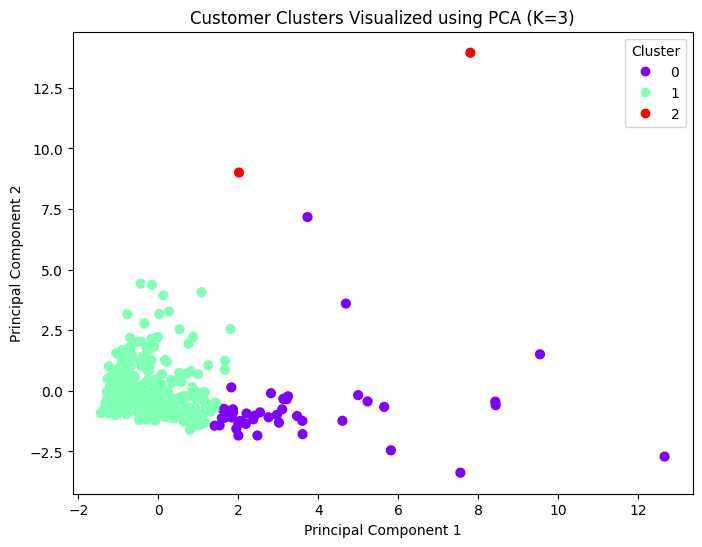

In [23]:
# PCA for 2D visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=labels, cmap='rainbow', s=40)
plt.title(f'Customer Clusters Visualized using PCA (K={best_k})')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.show()

To visualize the clusters, I applied Principal Component Analysis (PCA) to reduce the six standardized features to two principal components and plotted the customers in this 2D space, coloured by cluster. The plot shows that the clusters are reasonably separated, though some overlap is expected in real-world customer data.

## Part 3: Interpretations & Insights
After applying K-means clustering (K = 3), three clear customer groups emerged, each with distinct purchasing patterns. The clusters differ mainly in total purchase volume and the types of products customers tend to buy more. The Silhouette Score for K=3 (≈0.55) indicates well-separated and meaningful groups.

### **Cluster 1** - Regular / Low-to-Medium Buyers (Majority Customers — 393 customers)

This is the largest group. Customers in this cluster have moderate spending across all categories and do not specialize in any particular product.
They likely represent households, small shops, or consistent low-volume buyers.

**Key characteristics:**

Moderate:- Fresh, Milk, Grocery
Low:- Detergents_Paper and Delicassen

**Interpretation:**
General-purpose buyers with no extreme behavior. They form the core customer base.

### **Cluster 0** - High Grocery–Milk–Detergent Buyers (45 customers)
This group shows very high spending on Milk, Grocery, and Detergents/Paper, with moderately high Fresh spending.

**Key characteristics:**
Very high Grocery & Detergents_Paper
High Milk
Medium Fresh/Frozen
Higher-than-average purchase of essential daily-use products

**Interpretation:**
A targeted high-value segment focused on frequently consumed goods.

### **Cluster 2** — Very High-Spending, Niche Customers (Only 2 customers)
This tiny cluster has extremely high spending across several categories, especially Fresh, Frozen, Milk, and Delicassen. These are clear outlier customers.

**Key characteristics:**
Extremely high Fresh (34k+)
Very high Frozen (48k+)
Very high Milk and Delicassen
Small group because such customers are rare

**Interpretation:**
These customers behave fundamentally different from others, which is exactly why the algorithm isolated them into their own cluster.

## **Key Insights**

**1. Customer purchasing behavior is not uniform**
The dataset naturally divides into 3 groups: low/moderate buyers, specialized high-volume buyers, and extreme outliers.

**2. Milk, Grocery, and Detergents/Paper strongly influence segmentation**
These categories are highly correlated and help separate clusters.

**3. A small group of extremely high-volume customers exists**
Even though only 2 customers fall in this group, they show distinctly different spending patterns, validating K=3.

**4. Majority of customers fall into one broad segment**
This suggests that most customers purchase small quantities across categories, with only a small fraction contributing disproportionately to volume.

##**Limitations**

**1. Clusters are influenced by outliers**
Even though outliers represent real high-spending customers, they can slightly distort cluster boundaries.

**2. No demographic or behavioral data**
The dataset includes only product spending — no information about:
Type of business
Location beyond basic region
Frequency of purchase
Customer size or revenue
More features could lead to richer segmentation.

**3. Only numerical variables were used**
Patterns based on time, seasonality, or purchase frequency cannot be captured.

## **Recommendations**
**1. Design different marketing strategies for each cluster**

Cluster 1 → focus on promotions, loyalty programs

Cluster 0 → bulk deals, dedicated account management

Cluster 2 → long-term contracts, customized pricing

**2. Collect additional customer attributes**

Adding fields such as customer type (retailer, restaurant, distributor), frequency of orders, or annual revenue could significantly improve segmentation.

**3. Remove or separately analyze extreme outliers**

If business context suggests they are special clients, analyze them individually.